# Análise de Desempenho TCP vs R-UDP
**PPGCC/UFPI — Projeto de Redes de Computadores 2026-1**  
**Matrícula:** 20261005083  
**Aluno:** Luiz Nelson dos Santos Lima

Gráficos gerados a partir dos dados coletados via `tcpdump` e métricas da aplicação (Sockets Python + Docker).

## 1. Configuração do ambiente

In [1]:
# Substitua pela URL do seu repositório GitHub
GITHUB_REPO = 'https://github.com/luizznelson/redes-ppgcc-tf-fase1.git'

import os, sys

IN_COLAB = 'google.colab' in str(get_ipython())

if IN_COLAB:
    if not os.path.exists('redes-ppgcc-fase1'):
        os.system(f'git clone {GITHUB_REPO} redes-ppgcc-fase1')
    BASE = 'redes-ppgcc-fase1'
else:
    BASE = os.path.abspath(os.path.join(os.path.dirname(''), '..'))

LOG_DIR   = os.path.join(BASE, 'data', 'logs')
CSV_DIR   = os.path.join(BASE, 'data', 'csv')
PLOTS_DIR = os.path.join(BASE, 'data', 'plots')
os.makedirs(PLOTS_DIR, exist_ok=True)

print(f'BASE      : {BASE}')
print(f'LOG_DIR   : {LOG_DIR}')
print(f'CSV_DIR   : {CSV_DIR}')
print(f'PLOTS_DIR : {PLOTS_DIR}')

BASE      : c:\Users\VTX03095\Downloads\redes-ppgcc-fase1
LOG_DIR   : c:\Users\VTX03095\Downloads\redes-ppgcc-fase1\data\logs
CSV_DIR   : c:\Users\VTX03095\Downloads\redes-ppgcc-fase1\data\csv
PLOTS_DIR : c:\Users\VTX03095\Downloads\redes-ppgcc-fase1\data\plots


In [2]:
!pip install -q plotly seaborn pandas numpy matplotlib kaleido==0.2.1

In [3]:
import json
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from IPython.display import Image, display

SCENARIOS = ['A', 'B', 'C']
SCENARIO_LABELS = {
    'A': 'A (0% loss / 10ms)',
    'B': 'B (10% loss / 50ms)',
    'C': 'C (20% loss / 100ms)',
}
COLORS = {'TCP': '#2196F3', 'R-UDP': '#FF5722'}

def show_png(name):
    """Exibe o PNG salvo — visível no GitHub ao commitar o notebook com outputs."""
    path = os.path.join(PLOTS_DIR, name)
    if os.path.exists(path):
        display(Image(path))

## 2. Carregamento dos dados

In [4]:
def load_jsonl(path):
    records = []
    if not os.path.exists(path):
        return records
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass
    return records


def load_app_metrics():
    tcp_records  = load_jsonl(os.path.join(LOG_DIR, 'tcp_client_metrics.jsonl'))
    rudp_records = load_jsonl(os.path.join(LOG_DIR, 'rudp_client_metrics.jsonl'))
    all_records  = tcp_records + rudp_records
    if not all_records:
        print('[WARN] Nenhuma métrica encontrada. Verifique o caminho do Drive.')
        return pd.DataFrame()
    df = pd.DataFrame(all_records)
    df['scenario_label'] = df['scenario'].map(SCENARIO_LABELS)
    return df


def load_tcpdump_metrics():
    rows = []
    for sc in SCENARIOS:
        for proto in ['tcp', 'rudp']:
            pattern_new = os.path.join(CSV_DIR, f'scenario_{sc}_{proto}_rep*.csv')
            pattern_old = os.path.join(CSV_DIR, f'scenario_{sc}_{proto}.csv')
            csv_files = sorted(glob.glob(pattern_new)) or glob.glob(pattern_old)
            for csv_path in csv_files:
                df = pd.read_csv(csv_path)
                if df.empty:
                    continue
                total_bytes = df['length'].sum()
                pkt_count   = len(df)
                duration    = df['timestamp'].max() - df['timestamp'].min() if len(df) > 1 else 0
                throughput  = (total_bytes * 8) / duration / 1e6 if duration > 0 else 0
                rows.append({
                    'scenario': sc,
                    'protocol': proto.upper().replace('RUDP', 'R-UDP'),
                    'tcpdump_bytes': int(total_bytes),
                    'tcpdump_pkts':  int(pkt_count),
                    'tcpdump_duration_sec': round(duration, 4),
                    'tcpdump_throughput_mbps': round(throughput, 4),
                })
    return pd.DataFrame(rows) if rows else pd.DataFrame()


app_df     = load_app_metrics()
tcpdump_df = load_tcpdump_metrics()

print(f'Registros de aplicação : {len(app_df)}')
print(f'Registros de TCPDump   : {len(tcpdump_df)}')
app_df.head()

Registros de aplicação : 31
Registros de TCPDump   : 30


,protocol,bytes_received,elapsed_sec,throughput_mbps,auth,scenario,bytes_sent,client_elapsed_sec,client_throughput_mbps,window_size,total_packets,retransmissions,scenario_label
0,TCP,10485760.0,0.1424,588.9617,20261005083:Luiz Nelson dos Santos Lima,A,10485760,0.1429,587.0038,NaN,NaN,NaN,A (0% loss / 10ms)
1,TCP,10485760.0,0.1356,618.6135,20261005083:Luiz Nelson dos Santos Lima,A,10485760,0.1365,614.3885,NaN,NaN,NaN,A (0% loss / 10ms)
2,TCP,10485760.0,0.1368,613.3807,20261005083:Luiz Nelson dos Santos Lima,A,10485760,0.1376,609.5600,NaN,NaN,NaN,A (0% loss / 10ms)
3,TCP,10485760.0,0.1709,490.9124,20261005083:Luiz Nelson dos Santos Lima,A,10485760,0.1737,483.0742,NaN,NaN,NaN,A (0% loss / 10ms)
4,TCP,10485760.0,0.1273,659.1620,20261005083:Luiz Nelson dos Santos Lima,A,10485760,0.1287,651.7212,NaN,NaN,NaN,A (0% loss / 10ms)


## 3. Gráfico 1 — Throughput médio ± desvio padrão

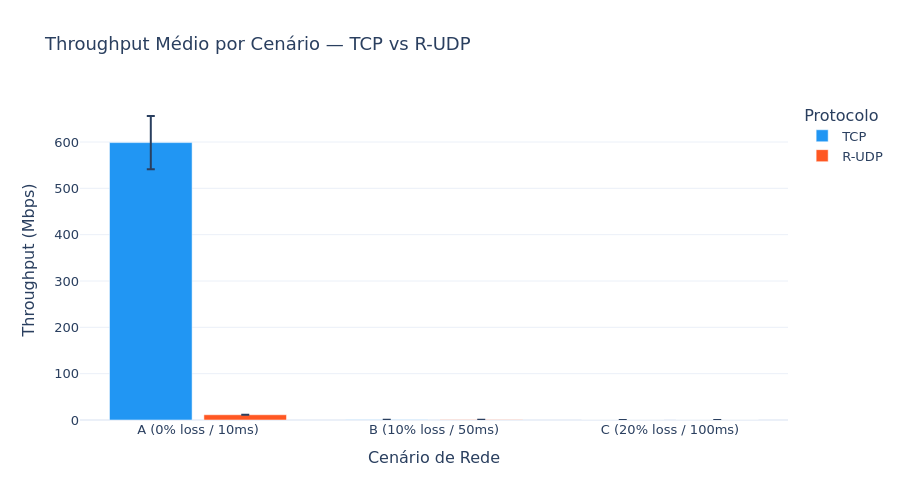

In [5]:
stats = app_df.groupby(['scenario', 'protocol'])['throughput_mbps'].agg(['mean', 'std']).reset_index()
stats.columns = ['scenario', 'protocol', 'mean', 'std']
stats['scenario_label'] = stats['scenario'].map(SCENARIO_LABELS)

fig = go.Figure()
for proto, color in COLORS.items():
    sub = stats[stats['protocol'] == proto]
    fig.add_trace(go.Bar(
        name=proto,
        x=sub['scenario_label'],
        y=sub['mean'],
        error_y=dict(type='data', array=sub['std'].fillna(0).tolist(), visible=True),
        marker_color=color,
        width=0.35,
    ))
fig.update_layout(
    title='Throughput Médio por Cenário — TCP vs R-UDP',
    xaxis_title='Cenário de Rede',
    yaxis_title='Throughput (Mbps)',
    barmode='group',
    template='plotly_white',
    legend_title='Protocolo',
    font=dict(size=13),
)
fig.write_html(os.path.join(PLOTS_DIR, 'throughput.html'))
fig.show()
show_png('throughput.png')

## 4. Gráfico 2 — Tempo de transferência por cenário

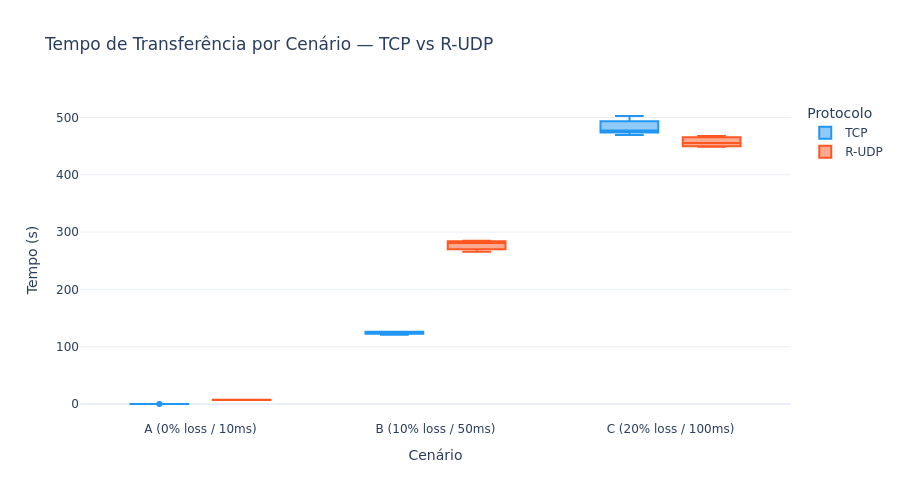

In [6]:
fig = px.box(
    app_df, x='scenario_label', y='elapsed_sec',
    color='protocol', color_discrete_map=COLORS,
    title='Tempo de Transferência por Cenário — TCP vs R-UDP',
    labels={'scenario_label': 'Cenário', 'elapsed_sec': 'Tempo (s)', 'protocol': 'Protocolo'},
    template='plotly_white',
    category_orders={'scenario_label': [SCENARIO_LABELS[s] for s in SCENARIOS]},
)
fig.write_html(os.path.join(PLOTS_DIR, 'latency.html'))
fig.show()
show_png('latency.png')

## 5. Gráfico 3 — Retransmissões R-UDP por cenário

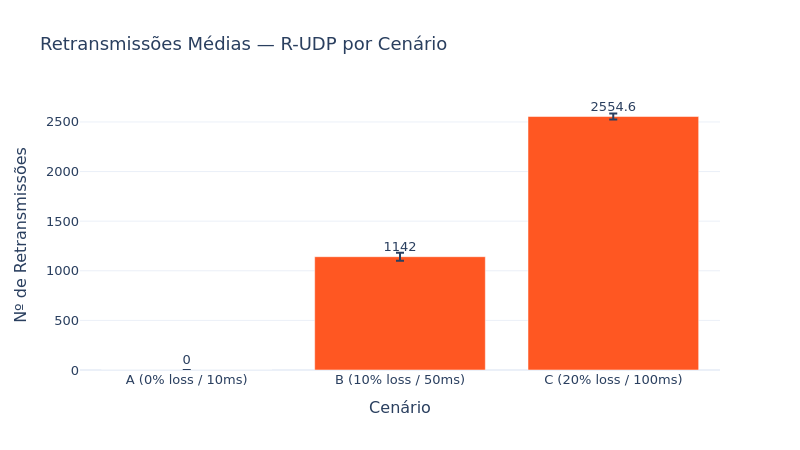

In [7]:
rudp = app_df[app_df['protocol'] == 'R-UDP'].copy()

if 'retransmissions' in rudp.columns and not rudp['retransmissions'].isna().all():
    stats_r = rudp.groupby('scenario')['retransmissions'].agg(['mean', 'std']).reset_index()
    stats_r['scenario_label'] = stats_r['scenario'].map(SCENARIO_LABELS)

    fig = go.Figure(go.Bar(
        x=stats_r['scenario_label'],
        y=stats_r['mean'],
        error_y=dict(type='data', array=stats_r['std'].fillna(0).tolist(), visible=True),
        marker_color='#FF5722',
        text=stats_r['mean'].round(1),
        textposition='outside',
    ))
    fig.update_layout(
        title='Retransmissões Médias — R-UDP por Cenário',
        xaxis_title='Cenário', yaxis_title='Nº de Retransmissões',
        template='plotly_white', font=dict(size=13),
    )
    fig.write_html(os.path.join(PLOTS_DIR, 'retransmissions.html'))
    fig.show()
    show_png('retransmissions.png')
else:
    print('[SKIP] Dados de retransmissão não disponíveis')

## 6. Gráfico 4 — Validação cruzada: Aplicação vs TCPDump

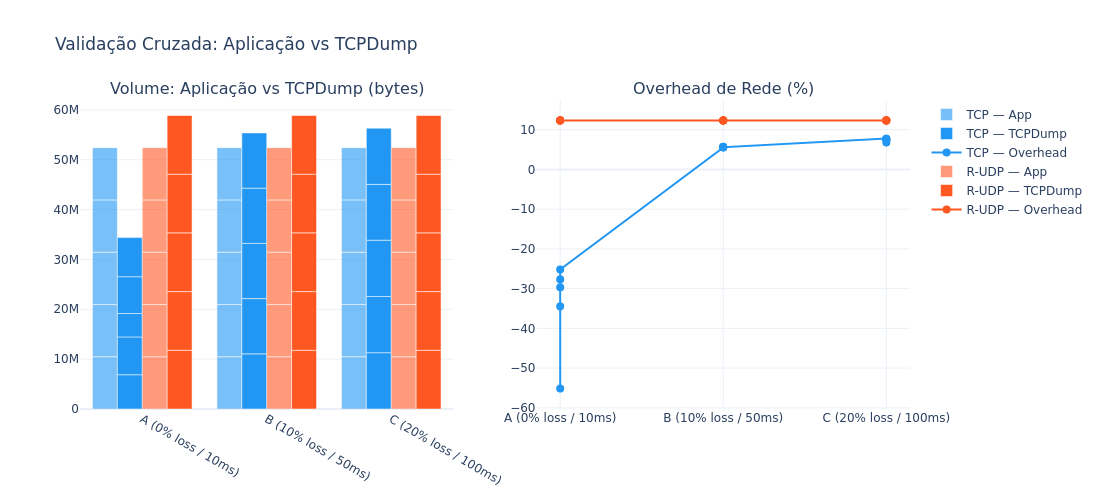

scenario protocol  app_bytes  tcpdump_bytes  overhead_pct
       A    R-UDP 10485760.0       11776631         12.31
       A    R-UDP 10485760.0       11776631         12.31
       A    R-UDP 10485760.0       11776631         12.31
       A    R-UDP 10485760.0       11776631         12.31
       A    R-UDP 10485760.0       11776631         12.31
       A      TCP 10485760.0        6872221        -34.46
       A      TCP 10485760.0        7583907        -27.67
       A      TCP 10485760.0        4703875        -55.14
       A      TCP 10485760.0        7374644        -29.67
       A      TCP 10485760.0        7844717        -25.19
       B    R-UDP 10485760.0       11776631         12.31
       B    R-UDP 10485760.0       11776631         12.31
       B    R-UDP 10485760.0       11776631         12.31
       B    R-UDP 10485760.0       11776631         12.31
       B    R-UDP 10485760.0       11776631         12.31
       B      TCP 10485760.0       11062957          5.50
       B      

In [8]:
if not tcpdump_df.empty:
    merged = app_df.groupby(['scenario', 'protocol'])['bytes_sent'].mean().reset_index()
    merged.columns = ['scenario', 'protocol', 'app_bytes']
    merged = merged.merge(
        tcpdump_df[['scenario', 'protocol', 'tcpdump_bytes']],
        on=['scenario', 'protocol'], how='left'
    )
    merged['overhead_pct'] = (
        (merged['tcpdump_bytes'] - merged['app_bytes']) / merged['app_bytes'] * 100
    ).round(2)
    merged['scenario_label'] = merged['scenario'].map(SCENARIO_LABELS)

    fig = make_subplots(rows=1, cols=2, subplot_titles=[
        'Volume: Aplicação vs TCPDump (bytes)',
        'Overhead de Rede (%)'
    ])
    for proto, color in COLORS.items():
        sub = merged[merged['protocol'] == proto]
        fig.add_trace(go.Bar(
            name=f'{proto} — App', x=sub['scenario_label'], y=sub['app_bytes'],
            marker_color=color, opacity=0.6, showlegend=True,
        ), row=1, col=1)
        fig.add_trace(go.Bar(
            name=f'{proto} — TCPDump', x=sub['scenario_label'], y=sub['tcpdump_bytes'],
            marker_color=color, opacity=1.0, showlegend=True,
        ), row=1, col=1)
        fig.add_trace(go.Scatter(
            name=f'{proto} — Overhead', x=sub['scenario_label'], y=sub['overhead_pct'],
            mode='lines+markers', marker=dict(color=color, size=8),
        ), row=1, col=2)

    fig.update_layout(
        title='Validação Cruzada: Aplicação vs TCPDump',
        template='plotly_white', font=dict(size=12), barmode='group'
    )
    fig.write_html(os.path.join(PLOTS_DIR, 'cross_validation.html'))
    fig.show()
    show_png('cross_validation.png')

    merged.to_csv(os.path.join(PLOTS_DIR, 'cross_validation_table.csv'), index=False)
    print(merged[['scenario', 'protocol', 'app_bytes', 'tcpdump_bytes', 'overhead_pct']].to_string(index=False))
else:
    print('[SKIP] CSVs do TCPDump não encontrados')

## 7. Gráfico 5 — Heatmap de desempenho

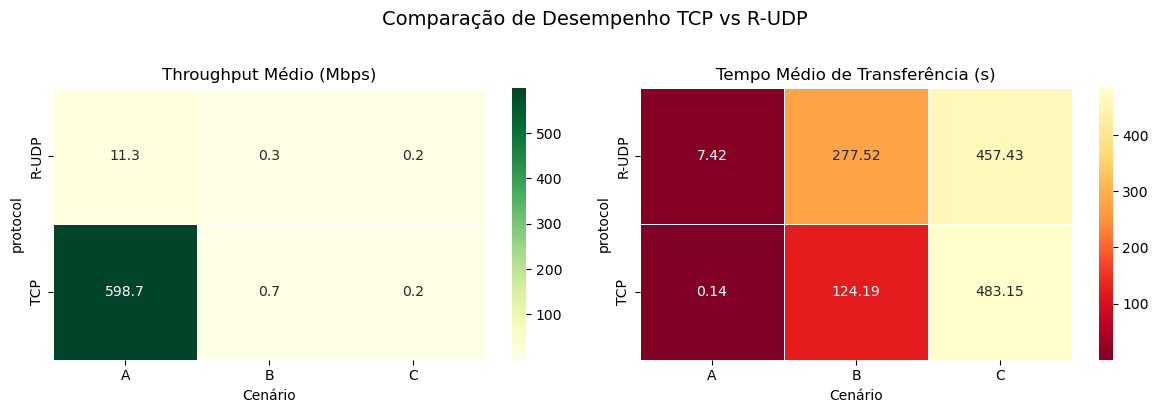

In [9]:
stats_h = app_df.groupby(['scenario', 'protocol']).agg(
    throughput=('throughput_mbps', 'mean'),
    elapsed=('elapsed_sec', 'mean'),
).reset_index()

pivot_tp = stats_h.pivot(index='protocol', columns='scenario', values='throughput')
pivot_el = stats_h.pivot(index='protocol', columns='scenario', values='elapsed')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(pivot_tp, annot=True, fmt='.1f', cmap='YlGn',
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Throughput Médio (Mbps)')
axes[0].set_xlabel('Cenário')

sns.heatmap(pivot_el, annot=True, fmt='.2f', cmap='YlOrRd_r',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Tempo Médio de Transferência (s)')
axes[1].set_xlabel('Cenário')

plt.suptitle('Comparação de Desempenho TCP vs R-UDP', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Resumo estatístico

In [10]:
summary = app_df.groupby(['protocol', 'scenario']).agg(
    n=('throughput_mbps', 'count'),
    tp_mean=('throughput_mbps', 'mean'),
    tp_std=('throughput_mbps', 'std'),
    elapsed_mean=('elapsed_sec', 'mean'),
).round(3)

print('=' * 60)
print(' RESUMO ESTATÍSTICO')
print('=' * 60)
print(summary.to_string())
print('=' * 60)
print(f'\nGráficos salvos em: {PLOTS_DIR}')

 RESUMO ESTATÍSTICO
                   n  tp_mean  tp_std  elapsed_mean
protocol scenario                                  
R-UDP    A         5   11.312   0.187         7.417
         B         5    0.302   0.009       277.525
         C         5    0.183   0.003       457.426
TCP      A         6  598.695  57.418         0.141
         B         5    0.676   0.012       124.194
         C         5    0.174   0.005       483.152

Gráficos salvos em: c:\Users\VTX03095\Downloads\redes-ppgcc-fase1\data\plots
